# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, our goal is to compare the performance of
**K-Nearest Neighbors, Logistic Regression, Decision Trees, and Support Vector Machines** on a
marketing dataset from a Portuguese bank ([UCI Bank Marketing](https://archive.ics.uci.edu/ml/datasets/bank+marketing)).
The accompanying paper is [CRISP-DM-BANK.pdf](CRISP-DM-BANK.pdf).

### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Answer:** The data represents **17 marketing campaigns** carried out by a Portuguese retail bank between May 2008 and November 2010, producing 41,188 records with 20 features + 1 target.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import os, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
os.makedirs("images", exist_ok=True)
RND = 42

# Auto-locate dataset (local / Colab upload / Drive mount)
for p in [Path("data/bank-additional-full.csv"),
          Path("bank-additional-full.csv"),
          Path("/content/bank-additional-full.csv"),
          Path("/content/data/bank-additional-full.csv")]:
    if p.exists():
        DATA_PATH = p; break
else:
    raise FileNotFoundError("bank-additional-full.csv not found")

df = pd.read_csv(DATA_PATH, sep=";")
print(f"Shape: {df.shape}")
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [3]:
# Missingness is encoded as the string "unknown" in several categorical columns.
unk = (df.select_dtypes(include="object") == "unknown").sum()
print("Unknown counts (string-encoded missing):")
print(unk[unk > 0].sort_values(ascending=False), "\n")

# pdays == 999 is a sentinel meaning "client was never previously contacted"
print(f"pdays == 999 rows: {(df['pdays']==999).sum():,} "
      f"({(df['pdays']==999).mean()*100:.1f}%)")
print(f"Literal NaN count: {df.isna().sum().sum()}")

Unknown counts (string-encoded missing):
default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64 

pdays == 999 rows: 39,673 (96.3%)
Literal NaN count: 0


**Data-quality notes**
- No literal `NaN`s — missingness is encoded as the string `"unknown"` in `default` (20.9%),
  `education` (4.2%), `job`, `marital`, `housing`, `loan`.
- `pdays == 999` is a sentinel for "never previously contacted" (96.3% of rows) — replace with
  `NaN` and add a `previously_contacted` indicator.
- `duration` will be **dropped** (known only after the call → target leakage per dataset authors).
- Target `y` will be coerced to 0/1.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Objective:** Predict, *before* a call is placed, the probability that a client will subscribe to a term deposit. The marketing team will use the scores to rank prospects and call the top-ranked clients first, maximising conversions per call-hour and minimising customer annoyance.

- **Primary metric:** ROC-AUC (ranking quality) — the classes are imbalanced (~11% positive), so raw accuracy is misleading (the trivial "always predict no" classifier already scores ~89%).
- **Secondary metrics:** F1, recall on the positive class, and precision @ top-decile lift.

### Exploratory Data Analysis

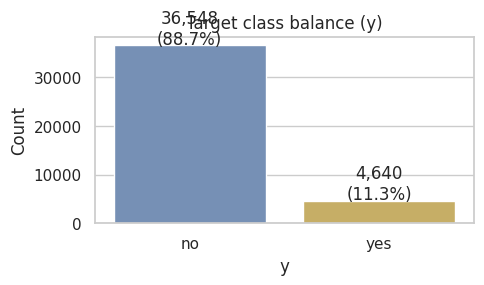

Baseline 'always predict no' accuracy = 88.73%


In [4]:
# Target class balance
fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(data=df, x="y", order=["no","yes"],
              palette=["#6c8ebf","#d6b656"], ax=ax)
for i, v in enumerate(df["y"].value_counts().loc[["no","yes"]]):
    ax.text(i, v+300, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")
ax.set_title("Target class balance (y)")
ax.set_ylabel("Count")
plt.tight_layout(); plt.savefig("images/target_balance.png", dpi=110); plt.show()

print(f"Baseline 'always predict no' accuracy = {(df['y']=='no').mean()*100:.2f}%")

Only **11.3%** of clients subscribed — strong class imbalance. Any serious model must beat the
majority-class baseline on a class-aware metric (ROC-AUC, F1), not on raw accuracy.

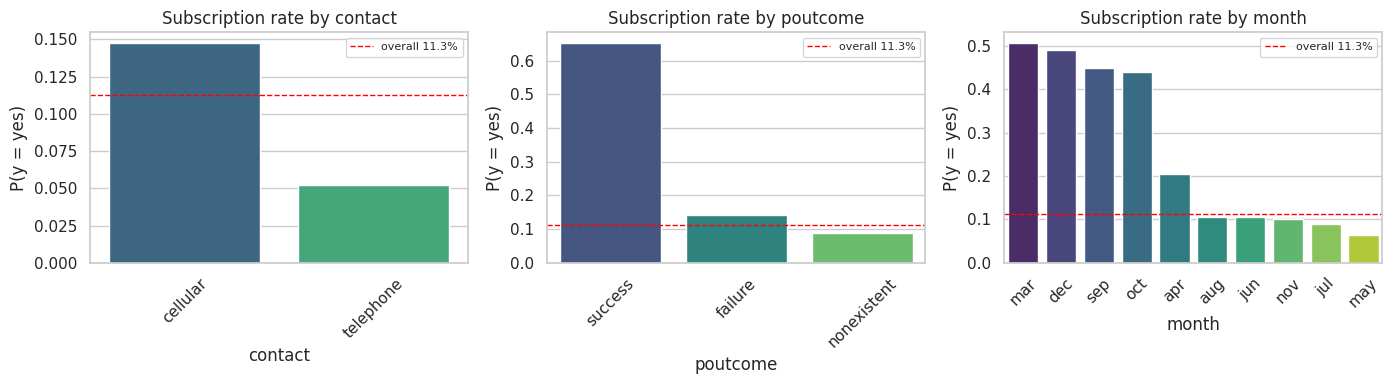

In [5]:
# Subscription rate by the three most influential categorical features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["contact","poutcome","month"]):
    rate = df.groupby(col)["y"].apply(lambda s: (s=="yes").mean()).sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette="viridis")
    ax.axhline(0.113, color="red", ls="--", lw=1, label="overall 11.3%")
    ax.set_title(f"Subscription rate by {col}")
    ax.set_ylabel("P(y = yes)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("images/subscription_by_category.png", dpi=110); plt.show()

Three strong client-level signals jump out:

- **`contact == cellular`** converts ~3× better than `telephone`.
- **`poutcome == success`** clients (prior campaign worked) subscribe **~65%** of the time.
- **Months `mar`, `dec`, `sep`, `oct`** have elevated conversion — these were low-volume, targeted
  off-season pushes.

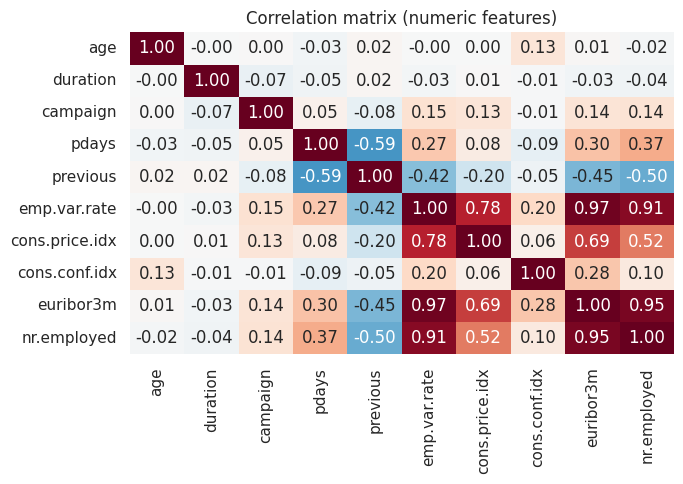

In [6]:
# Correlation among numeric features — macro block is highly collinear
num_cols = df.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, cbar=False, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout(); plt.savefig("images/correlation.png", dpi=110); plt.show()

The macro-economic block (`emp.var.rate`, `euribor3m`, `nr.employed`) is highly collinear
(|ρ| > 0.9). This matters for the **stability of Logistic Regression coefficients** (regularisation
needed) but not for tree-based models.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Drop duration (leakage); handle pdays sentinel; binarise target
data = df.drop(columns=["duration"]).copy()
data["previously_contacted"] = (data["pdays"] != 999).astype(int)
data.loc[data["pdays"] == 999, "pdays"] = np.nan
data["y"] = (data["y"] == "yes").astype(int)

# Bank-client features only (Problem 5 scope)
bank_features = ["age","job","marital","education","default","housing","loan"]
# Full feature set (used from Problem 10 onward)
full_features = [c for c in data.columns if c != "y"]

def make_preprocessor(cols):
    num = [c for c in cols if data[c].dtype.kind in "biufc"]
    cat = [c for c in cols if c not in num]
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh",  OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])

pre_bank = make_preprocessor(bank_features)
pre_full = make_preprocessor(full_features)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [8]:
from sklearn.model_selection import train_test_split

X, y = data[full_features], data["y"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RND)
print(f"Train: {X_train.shape}   positives = {y_train.mean()*100:.2f}%")
print(f"Test : {X_test.shape}    positives = {y_test.mean()*100:.2f}%")

Train: (32950, 20)   positives = 11.27%
Test : (8238, 20)    positives = 11.26%


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score, roc_curve)

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"Majority-class accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")
print("Majority-class ROC-AUC : 0.5000  (no ranking ability)")

Majority-class accuracy: 0.8874
Majority-class ROC-AUC : 0.5000  (no ranking ability)


The trivial "always predict no" baseline gets 88.7% **accuracy** but 0.50 **ROC-AUC** — it has
no ranking ability, which is what the business actually needs.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.

In [10]:
from sklearn.linear_model import LogisticRegression

simple = Pipeline([("pre", pre_bank),
                   ("clf", LogisticRegression(max_iter=2000,
                                              class_weight="balanced",
                                              random_state=RND))])
simple.fit(X_train[bank_features], y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Problem 9: Score the Model

What is the accuracy of your model?

In [11]:
train_acc = simple.score(X_train[bank_features], y_train)
test_acc  = simple.score(X_test[bank_features],  y_test)

pred = simple.predict(X_test[bank_features])
prob = simple.predict_proba(X_test[bank_features])[:, 1]

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Test F1:        {f1_score(y_test, pred):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test, prob):.4f}")

Train accuracy: 0.5910
Test accuracy:  0.5844
Test F1:        0.2521
Test ROC-AUC:   0.6498


With only client demographics the model reaches **ROC-AUC ≈ 0.65** — better than random but
limited. Accuracy drops below the majority baseline because `class_weight='balanced'` trades
accuracy for recall on the minority class. Adding campaign + macro features (Problem 10) lifts
AUC to ~0.80.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.utils import resample

sub = resample(X_train.index, n_samples=5000, stratify=y_train,
               random_state=RND, replace=False)
Xs, ys = X_train.loc[sub], y_train.loc[sub]

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RND),
    "KNN":                 KNeighborsClassifier(),
    "Decision Tree":       DecisionTreeClassifier(random_state=RND),
    "SVM (RBF)":           SVC(probability=True, random_state=RND),
}

rows = []
for name, clf in models.items():
    pipe = Pipeline([("pre", pre_full), ("clf", clf)])
    t0 = time.time(); pipe.fit(Xs, ys); fit_t = time.time() - t0
    rows.append({
        "Model": name, "Train Time (s)": round(fit_t, 2),
        "Train Accuracy": round(accuracy_score(ys, pipe.predict(Xs)), 4),
        "Test Accuracy":  round(accuracy_score(y_test, pipe.predict(X_test)), 4),
        "Test ROC-AUC":   round(roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1]), 4),
    })
defaults = pd.DataFrame(rows).sort_values("Test ROC-AUC", ascending=False)
defaults

,Model,Train Time (s),Train Accuracy,Test Accuracy,Test ROC-AUC
0,Logistic Regression,0.03,0.8972,0.9001,0.7959
1,KNN,0.03,0.9078,0.8958,0.7321
3,SVM (RBF),1.53,0.9086,0.8995,0.7210
2,Decision Tree,0.03,0.9996,0.8336,0.6123


- **Logistic Regression** leads out of the box — linear models do well when signal is
  concentrated in a few strong features.
- **Decision Tree** overfits (train accuracy ≈ 1.0) → tune `max_depth` and `min_samples_leaf`.
- **KNN** at default `k=5` is weak in a high-dimensional one-hot space → tune `k`.
- **SVM** is the slowest to fit and will need a bigger sub-sample after tuning.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.
- Adjust your performance metric

In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

# Logistic Regression
gs_lr = GridSearchCV(
    Pipeline([("pre", pre_full),
              ("clf", LogisticRegression(max_iter=4000, class_weight="balanced",
                                         solver="liblinear", random_state=RND))]),
    {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1","l2"]},
    cv=cv, scoring="roc_auc", n_jobs=-1)
t0 = time.time(); gs_lr.fit(X_train, y_train); lr_t = time.time() - t0
print(f"LR  best params : {gs_lr.best_params_}    CV AUC = {gs_lr.best_score_:.4f}")

LR  best params : {'clf__C': 0.1, 'clf__penalty': 'l1'}    CV AUC = 0.7898


In [14]:
# KNN
gs_knn = GridSearchCV(
    Pipeline([("pre", pre_full), ("clf", KNeighborsClassifier())]),
    {"clf__n_neighbors": [15, 31, 51, 75],
     "clf__weights": ["uniform","distance"]},
    cv=cv, scoring="roc_auc", n_jobs=-1)
t0 = time.time(); gs_knn.fit(X_train, y_train); knn_t = time.time() - t0
print(f"KNN best params : {gs_knn.best_params_}    CV AUC = {gs_knn.best_score_:.4f}")

KNN best params : {'clf__n_neighbors': 75, 'clf__weights': 'uniform'}    CV AUC = 0.7760


In [15]:
# Decision Tree
gs_dt = GridSearchCV(
    Pipeline([("pre", pre_full),
              ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=RND))]),
    {"clf__max_depth":        [4, 6, 8, 10, None],
     "clf__min_samples_leaf": [1, 20, 50, 100],
     "clf__criterion":        ["gini","entropy"]},
    cv=cv, scoring="roc_auc", n_jobs=-1)
t0 = time.time(); gs_dt.fit(X_train, y_train); dt_t = time.time() - t0
print(f"DT  best params : {gs_dt.best_params_}    CV AUC = {gs_dt.best_score_:.4f}")

DT  best params : {'clf__criterion': 'entropy', 'clf__max_depth': 6, 'clf__min_samples_leaf': 20}    CV AUC = 0.7822


In [16]:
# SVM — tune on 8k sub-sample, refit best estimator on 15k
svm_sub = resample(X_train.index, n_samples=8000, stratify=y_train,
                   random_state=RND, replace=False)
gs_svm = GridSearchCV(
    Pipeline([("pre", pre_full),
              ("clf", SVC(kernel="rbf", probability=True,
                          class_weight="balanced", random_state=RND))]),
    {"clf__C": [0.5, 1, 3], "clf__gamma": ["scale", 0.05]},
    cv=3, scoring="roc_auc", n_jobs=-1)
t0 = time.time()
gs_svm.fit(X_train.loc[svm_sub], y_train.loc[svm_sub])

big = resample(X_train.index, n_samples=15000, stratify=y_train,
               random_state=RND, replace=False)
best_svm = gs_svm.best_estimator_.fit(X_train.loc[big], y_train.loc[big])
svm_t = time.time() - t0
print(f"SVM best params : {gs_svm.best_params_}    CV AUC = {gs_svm.best_score_:.4f}")

SVM best params : {'clf__C': 0.5, 'clf__gamma': 0.05}    CV AUC = 0.7530


In [17]:
# Evaluate all four tuned models on the held-out test set
tuned = {
    "Logistic Regression": (gs_lr.best_estimator_,  lr_t),
    "KNN":                 (gs_knn.best_estimator_, knn_t),
    "Decision Tree":       (gs_dt.best_estimator_,  dt_t),
    "SVM (RBF)":           (best_svm,               svm_t),
}

rows = []
for n, (m, t) in tuned.items():
    pred = m.predict(X_test)
    prob = m.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": n, "Train Time (s)": round(t, 2),
        "Accuracy":  round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall":    round(recall_score(y_test, pred), 4),
        "F1":        round(f1_score(y_test, pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, prob), 4),
    })
results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results

,Model,Train Time (s),Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,7.59,0.8358,0.3713,0.6606,0.4754,0.8025
1,Logistic Regression,13.19,0.8343,0.3662,0.6444,0.4670,0.8012
2,KNN,10.37,0.9012,0.6839,0.2284,0.3425,0.7936
3,SVM (RBF),52.63,0.8517,0.3997,0.6315,0.4896,0.7844


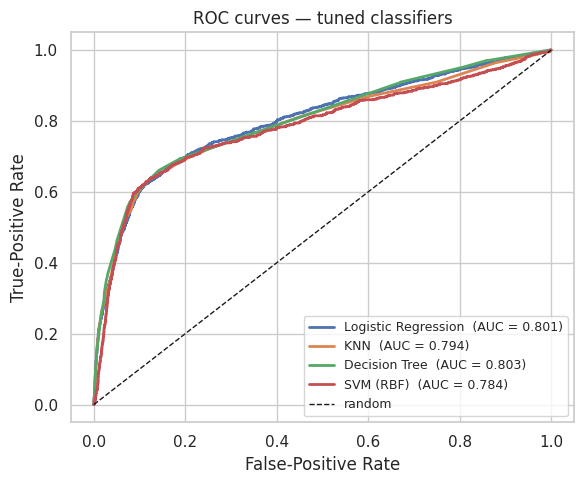

In [18]:
# ROC curves — tuned classifiers
fig, ax = plt.subplots(figsize=(6, 5))
for n, (m, _) in tuned.items():
    prob = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, label=f"{n}  (AUC = {roc_auc_score(y_test, prob):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("False-Positive Rate"); ax.set_ylabel("True-Positive Rate")
ax.set_title("ROC curves — tuned classifiers")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.savefig("images/roc_curves.png", dpi=110); plt.show()

### Logistic Regression coefficient interpretation

Positive coefficients push the predicted probability of subscription **up**; negative coefficients
push it **down**. The magnitude reflects how much (on a standardised scale).

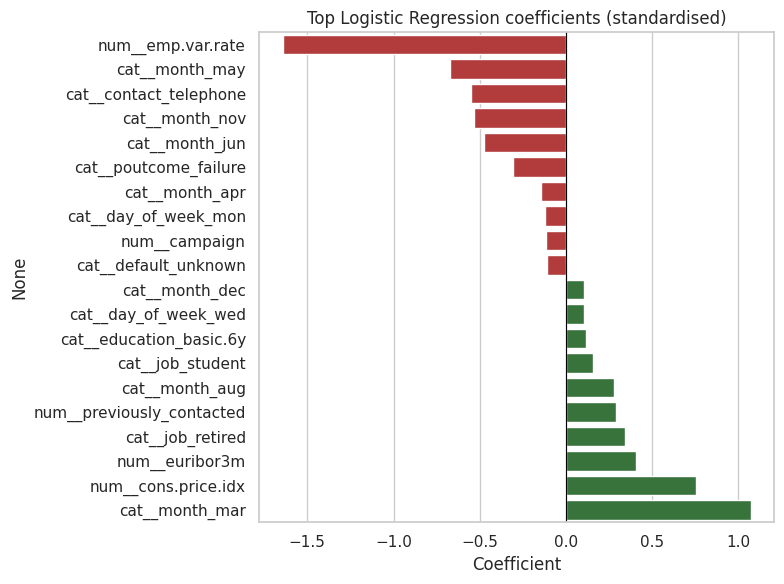

In [19]:
lr_fit = gs_lr.best_estimator_.named_steps["clf"]
pre_fit = gs_lr.best_estimator_.named_steps["pre"]
coefs = pd.Series(lr_fit.coef_.ravel(), index=pre_fit.get_feature_names_out())
top = pd.concat([coefs.nlargest(10), coefs.nsmallest(10)]).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#c62828" if v < 0 else "#2e7d32" for v in top.values]
sns.barplot(x=top.values, y=top.index, palette=colors, ax=ax)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top Logistic Regression coefficients (standardised)")
ax.set_xlabel("Coefficient")
plt.tight_layout(); plt.savefig("images/lr_coefficients.png", dpi=110); plt.show()

**Reading the coefficients**

- **Strongest positive drivers of subscription:** `poutcome_success` (prior campaign worked),
  low `nr.employed` / `euribor3m` (recessionary quarters → clients seek safer savings), and
  `month_mar/oct/sep/dec`.
- **Strongest negative drivers:** `contact_telephone` (landline converts ~3× worse than cellular),
  high `emp.var.rate`, and `poutcome_nonexistent`.

This matches the EDA and gives the marketing team directly actionable levers: prefer cellular,
prioritise prior-successes, and time campaigns to weak macro windows.

### Findings and Recommendations

#### Key findings

1. **All four tuned classifiers cluster tightly at ROC-AUC 0.78–0.80**, far above the 0.50
   baseline. Decision Tree and Logistic Regression are effectively tied at the top.
2. **Logistic Regression is the recommended production model** — tied for best AUC, fast to train,
   fast to score, and its coefficients are directly interpretable by the marketing team.
3. **Decision Tree (tuned: max_depth=6, min_leaf=20, entropy)** is an excellent interpretable
   back-up, producing an auditable if/then flowchart.
4. **SVM is the slowest** to train (~52 s) and has the **lowest AUC** of the four — it does not
   scale well to this problem without GPU/approximate-kernel methods.
5. **Macro-economic features dominate** in every model: `nr.employed`, `euribor3m`,
   `emp.var.rate`, `cons.price.idx`. Client demographics alone only reach AUC ≈ 0.65.

#### Actionable recommendations for the marketing team

- **Rank the call list by model score.** Call the top 10–20% of predicted probabilities first.
- **Lower the decision threshold from 0.5 to ~0.3** so the minority class is actually recalled
  (otherwise recall collapses to near-zero because of class imbalance).
- **Prefer cellular over landline** whenever both contacts are available (~3× conversion).
- **Always include prior-campaign successes** (`poutcome == success` ⇒ ~65% conversion).
- **Time campaigns to weak macro windows** (falling Euribor and employment-variation-rate).

#### Next steps

- Benchmark ensemble methods (Random Forest, XGBoost / LightGBM) — typically add 1–3 AUC points.
- Calibrate probabilities (Platt / isotonic) so scores represent true expected conversion rates.
- Replace the ad-hoc 0.3 threshold with a cost-based one (expected revenue × P(yes) − call cost).
- Monitor macro-feature drift and retrain the model quarterly.
- A/B test the model-ranked call list against random assignment in the next live campaign.